# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 13     |  |
| :-------------|:-------------|
| Oskar van Velze | 6044247 |
| Sarah Ilyas | 6223265 |
| Daan van der Molen | 6530095 |

In [73]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Oskar','Daan']

## Opdracht 1: Planning.

| Planning Groep: 13     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren | 10:45-11:30 |
| Iteratie 0 | 11:30-12:15 |
| Testmeting | 12:15-12:30 |
| Pauze | 12:30-13:45 |
| Iteratie 1 | 13:45-14:30 |
| Meer itereren | 14:30-16:00 |
| Test | 16:00 |

## Opdracht 2: Import libs.

In [74]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 13
<img src="kalibratieopstelling.jpg" width="400">

rico = 30.49141040058309 +- 0.24900312752503598
b = -94.71378610934217 +- 7.724677332459633


<function matplotlib.pyplot.show(close=None, block=None)>

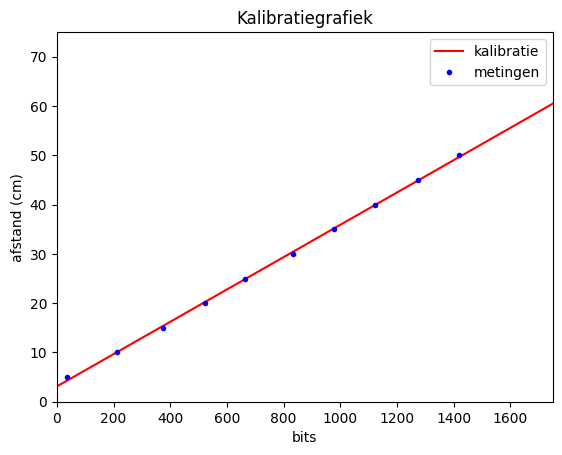

In [75]:
# verwerk hier jullie kalibratiemetingen

afstand = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50])#*1e-2
arduinounit = np.array([37, 213, 375, 522, 663, 834, 978, 1124, 1273, 1419])

def kalibratie(x, a, b):
    return a*x + b

def invkalibratie(y, a, b):
    return (y - b) / a

var, cov = curve_fit(invkalibratie, arduinounit, afstand)
print("rico =",var[0], "+-", np.sqrt(cov[0,0]))
print("b =", var[1], "+-", np.sqrt(cov[1,1]))

xvariabelen = np.linspace(0, 1500, 100)


plt.figure()
plt.plot(kalibratie(xvariabelen, var[0], var[1]), xvariabelen, 'r-', label='kalibratie')
plt.plot(arduinounit, afstand, 'b.', label='metingen')
plt.ylabel('afstand (cm)')
plt.xlabel('bits')
plt.title('Kalibratiegrafiek')
plt.xlim(0,1750)
plt.ylim(0,75)
plt.legend()
plt.show


## Opdracht 4: Test meting

In [76]:


testafstandmetingen = np.array([50.33, 51.92, 55.35, 48.79, 46.33]) # laatste 2 ongeldig

print(testafstandmetingen*0.5, "cm")

[25.165 25.96  27.675 24.395 23.165] cm


Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  40   0  30  25.165
1   0  30   0  20  25.960
2   0  10   0  20  27.675
3  40   0  30   0  24.395
4  30   0  20   0  23.165


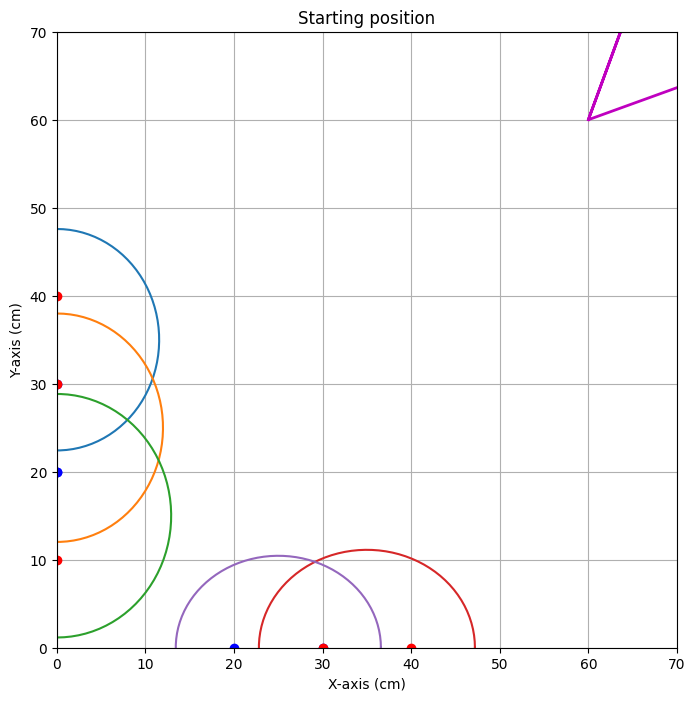


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=119.694


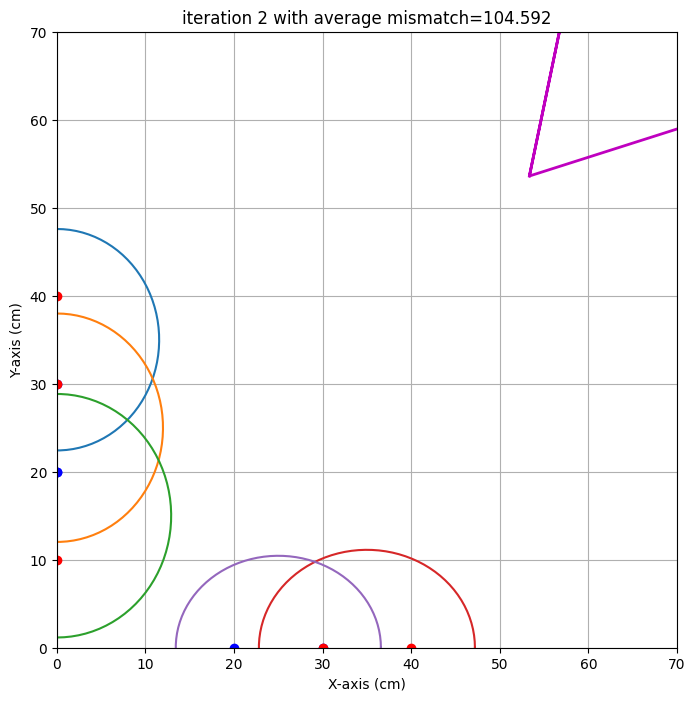

end iteration 2 with average mismatch=104.592


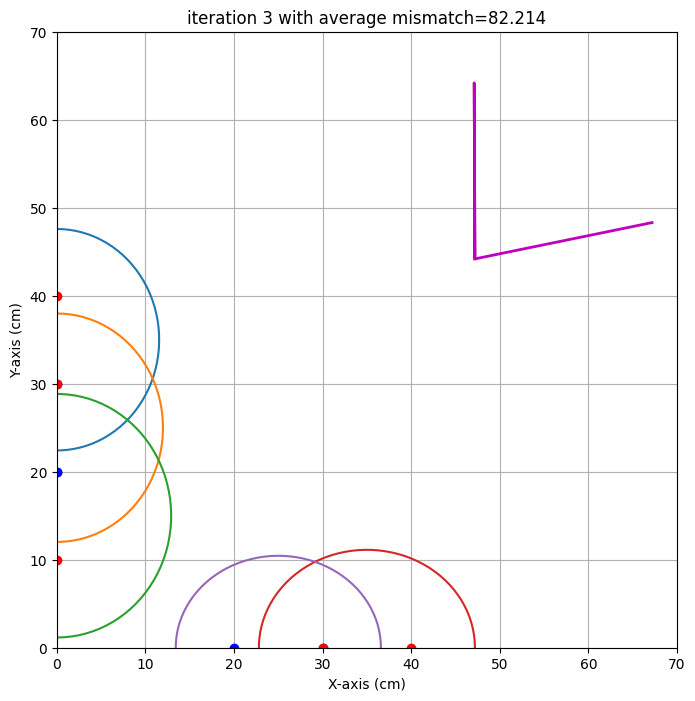

end iteration 3 with average mismatch=82.214


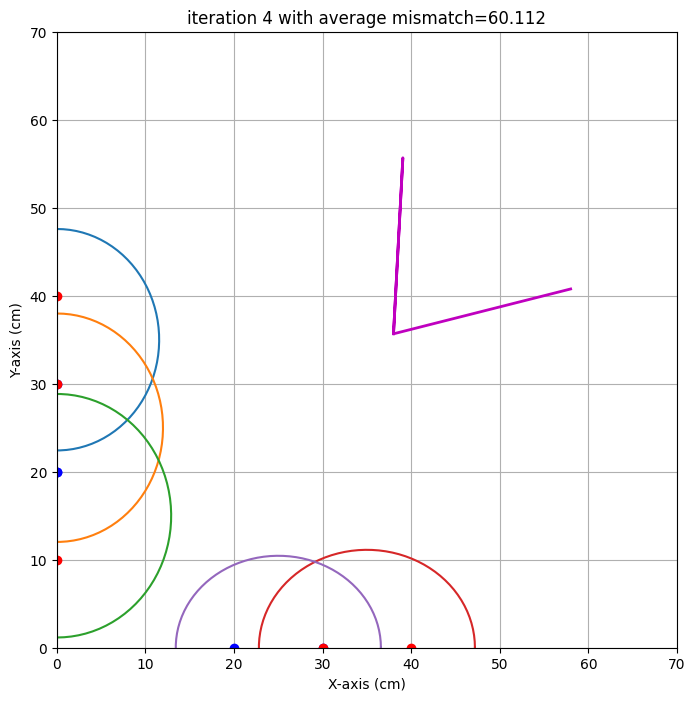

end iteration 4 with average mismatch=60.112


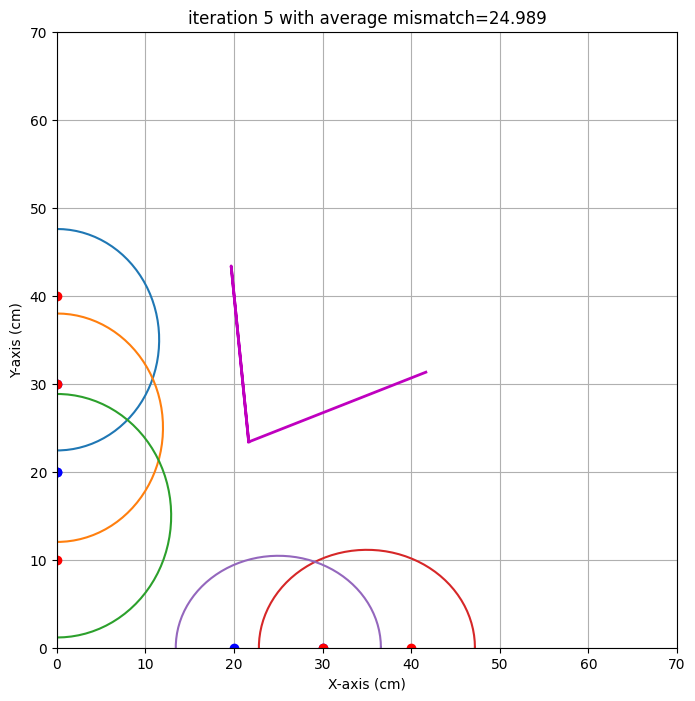

end iteration 5 with average mismatch=24.989


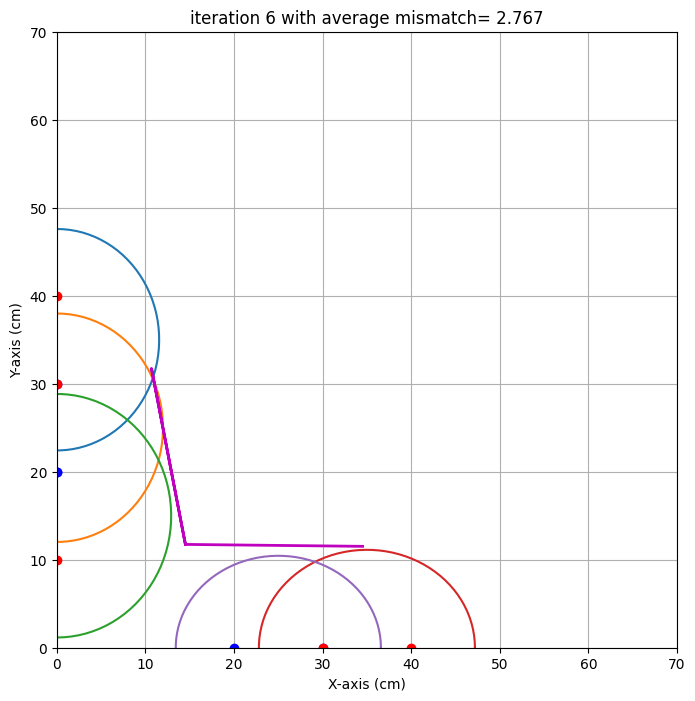

end iteration 6 with average mismatch= 2.767


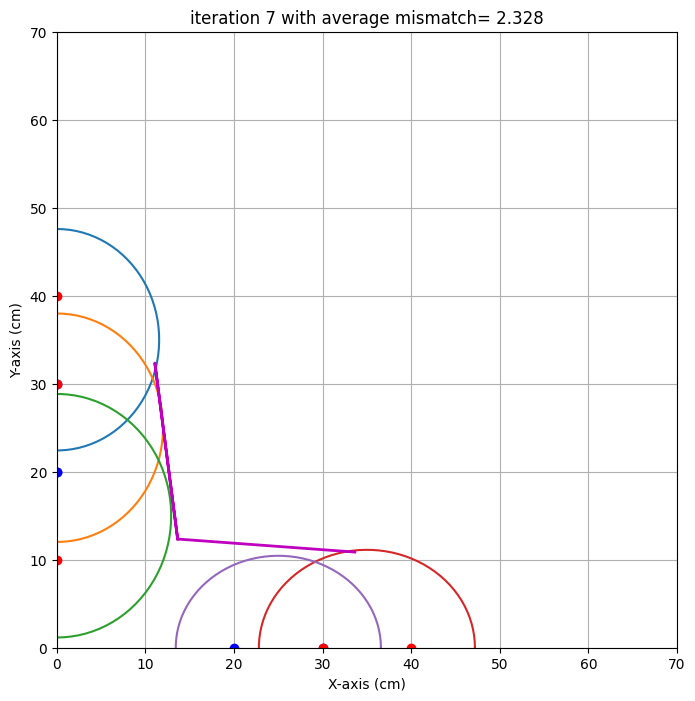

end iteration 7 with average mismatch= 2.328
end iteration 8 with average mismatch= 2.181
end iteration 9 with average mismatch= 2.098
end iteration 10 with average mismatch= 2.077
end iteration 11 with average mismatch= 2.076
end iteration 12 with average mismatch= 2.076
end iteration 13 with average mismatch= 2.076
end iteration 14 with average mismatch= 2.076
end iteration 15 with average mismatch= 2.073
end iteration 16 with average mismatch= 2.073
end iteration 17 with average mismatch= 2.073
end iteration 18 with average mismatch= 2.073
end iteration 19 with average mismatch= 2.016
end iteration 20 with average mismatch= 1.996
end iteration 21 with average mismatch= 1.996
end iteration 22 with average mismatch= 1.996
end iteration 23 with average mismatch= 1.937
end iteration 24 with average mismatch= 1.934
end iteration 25 with average mismatch= 1.933
end iteration 26 with average mismatch= 1.932
end iteration 27 with average mismatch= 1.932
end iteration 28 with average mismatc

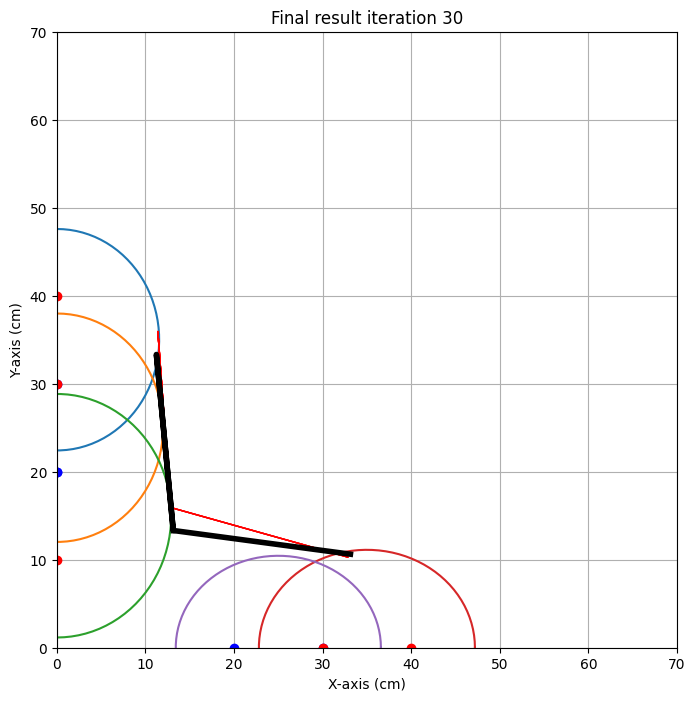

In [77]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.



                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,25.165],
    [0,30,0,20,25.96],
    [0,10,0,20,27.675],
    [40,0,30,0,24.395],
    [30,0,20,0,23.165]
    #,[10,0,20,0,6.0],
    #[10,0,0,10,7.0]    
    ])


resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [78]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 13.1 cm met een standaardafwijking van 0.3 cm 
y0: 13.3 cm met een standaardafwijking van 2.6 cm 
alpha: -7.7 graden met een standaardafwijking van 8.1 graad 
beta: -5.5 graden met een standaardafwijking van 1.3 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Oskar]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="iteratie0OVV.jpg" width="400">

#### algoritme [Sarah]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="iteratie0Sarah.jpeg" width="400">

#### algoritme [naam derde student]
Voeg een foto in van het algoritme van het derde groepslid
<img src="iteratie0Daan.jpeg" width="400">

In [79]:
#

## Opdracht 6: Test iteratie 0.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  80   0  83.42
1  60   0  70   0  66.32
2  50   0  60   0  62.89
3  40   0  50   0  60.27
4   0  50   0  60  88.47
5   0  40   0  50  84.06
6   0  30   0  40  83.28
7   0  20   0  30  81.04


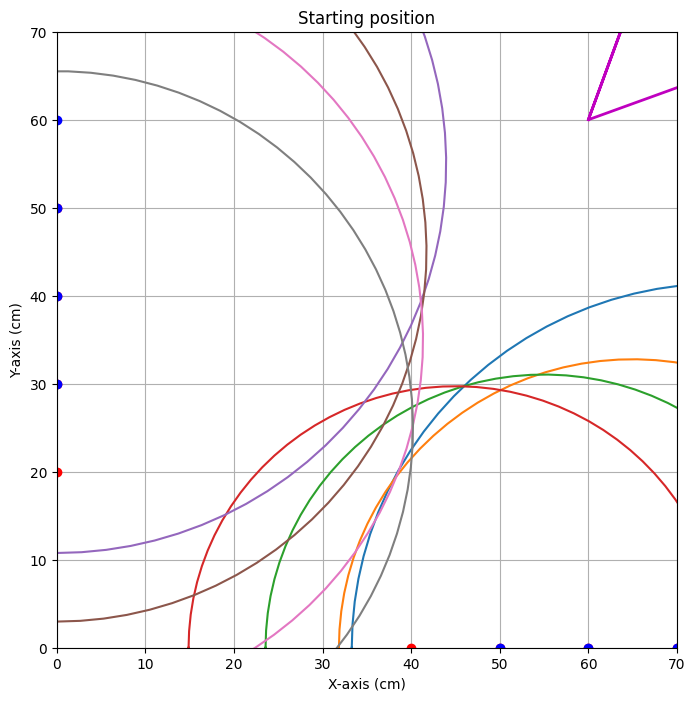


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.854


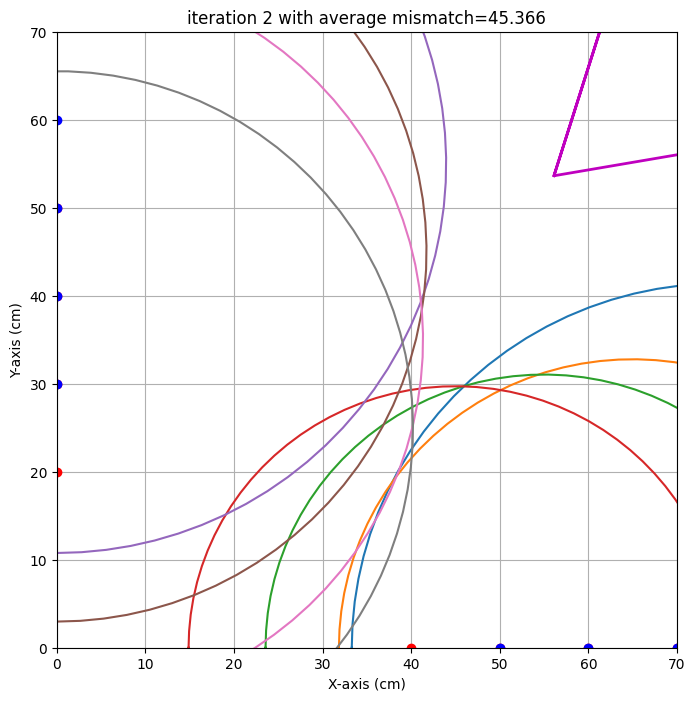

end iteration 2 with average mismatch=45.366


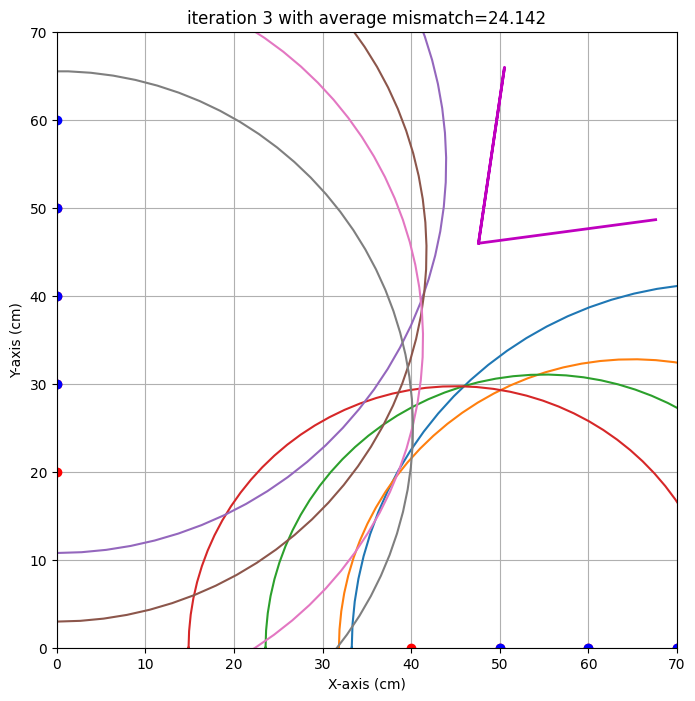

end iteration 3 with average mismatch=24.142


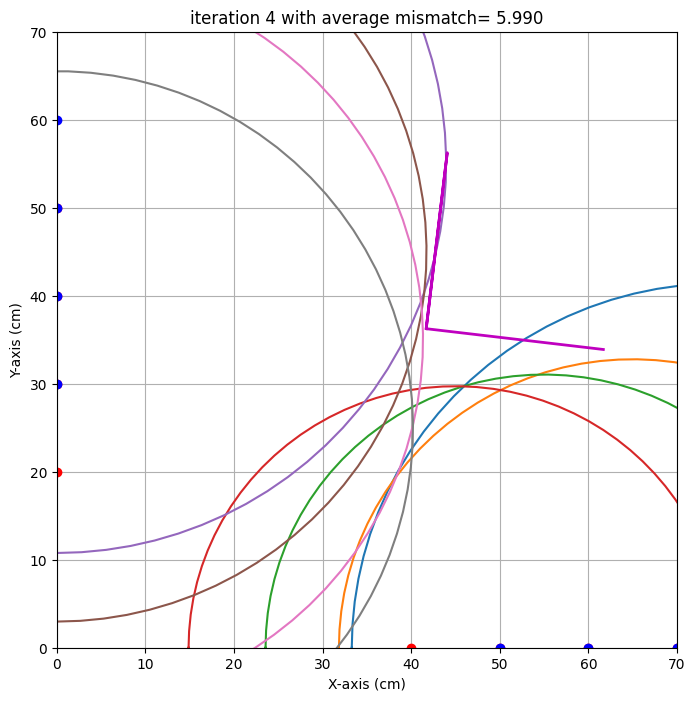

end iteration 4 with average mismatch= 5.990


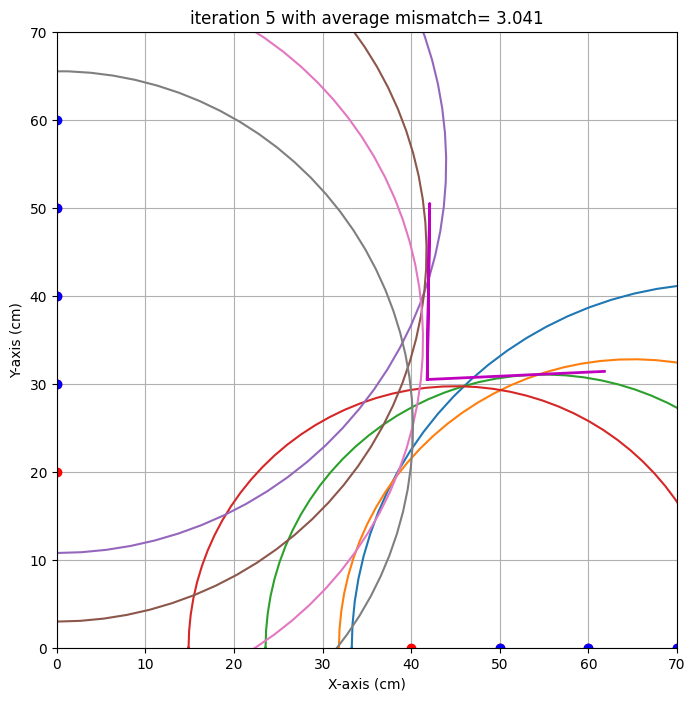

end iteration 5 with average mismatch= 3.041


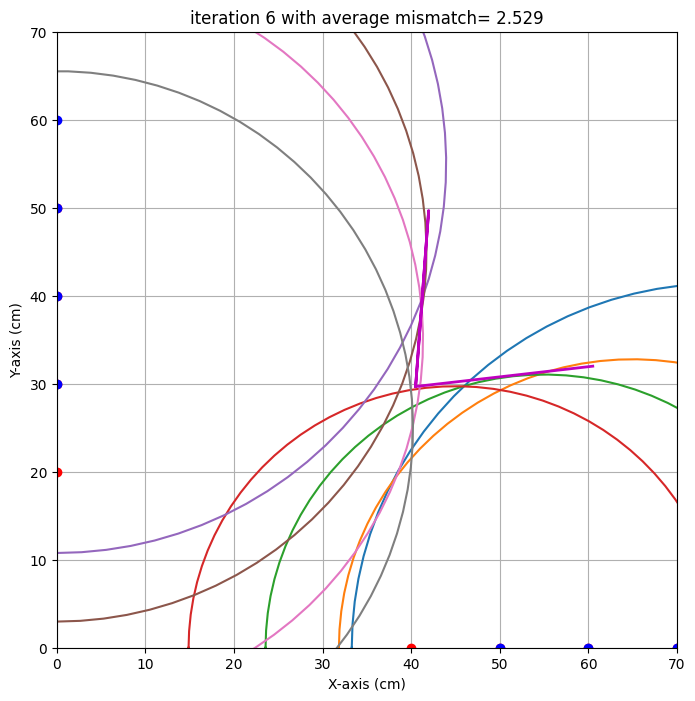

end iteration 6 with average mismatch= 2.529


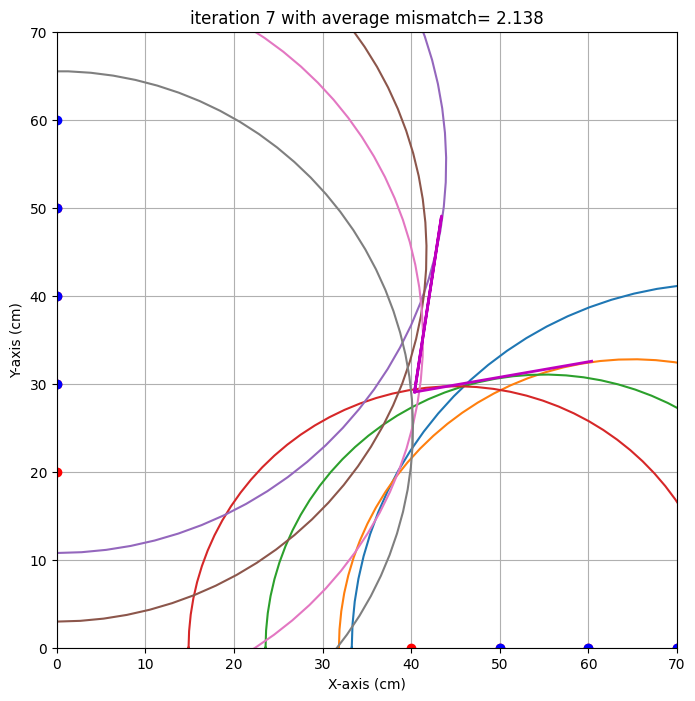

end iteration 7 with average mismatch= 2.138
end iteration 8 with average mismatch= 2.129
end iteration 9 with average mismatch= 2.104
end iteration 10 with average mismatch= 2.093
end iteration 11 with average mismatch= 2.071
end iteration 12 with average mismatch= 2.050
end iteration 13 with average mismatch= 2.029
end iteration 14 with average mismatch= 2.024
end iteration 15 with average mismatch= 2.022
end iteration 16 with average mismatch= 2.020
end iteration 17 with average mismatch= 2.020
end iteration 18 with average mismatch= 2.020
end iteration 19 with average mismatch= 2.020
end iteration 20 with average mismatch= 2.020
end iteration 21 with average mismatch= 2.020
end iteration 22 with average mismatch= 2.020
end iteration 23 with average mismatch= 2.020
end iteration 24 with average mismatch= 2.020
end iteration 25 with average mismatch= 2.020
end iteration 26 with average mismatch= 2.020
end iteration 27 with average mismatch= 2.020
end iteration 28 with average mismatc

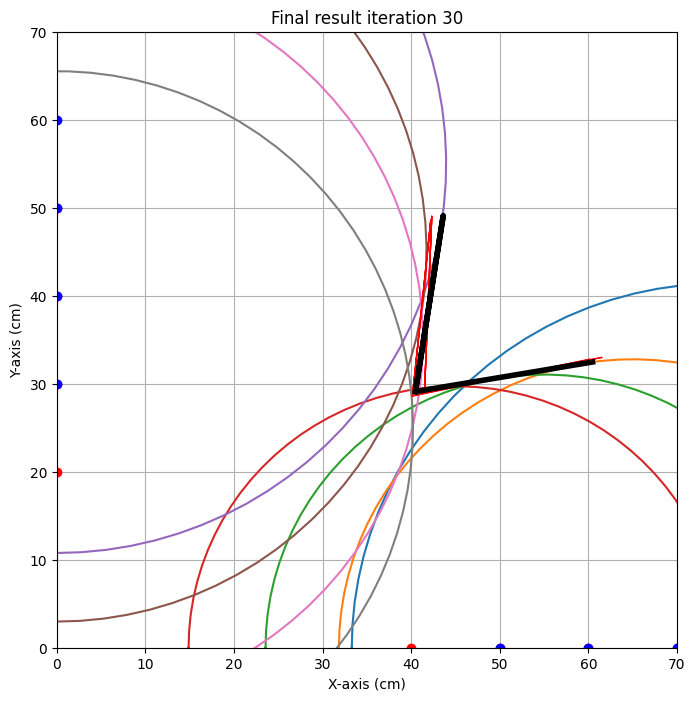

In [80]:
#datatest = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#     [70, 0, 80, 0, 83.42]
#    ,[60, 0, 70, 0, 66.32]
#    ,[50, 0, 60, 0, 62.89]
#    ,[40, 0, 50, 0, 60.27]
#    ,[0, 50, 0, 60, 88.47]
#    ,[0,40,0,50, 84.06]
#    ,[0, 30, 0, 40, 83.28]
#    ,[0, 20, 0, 30, 81.04]
#    ])

resultaatdatatest = imagingDEF.imagingDEF(datatest)

In [86]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 37,
           'y0': 26,
           'alpha': 25,
           'beta': 10,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Oskar' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [70, 0, 80, 0, 83.42]
    ,[60, 0, 70, 0, 66.32]
    ,[50, 0, 60, 0, 62.89]
    ,[40, 0, 50, 0, 60.27]
    ,[0, 50, 0, 60, 88.47]
    ,[0,40,0,50, 84.06]
    ,[0, 30, 0, 40, 83.28]
    ,[0, 20, 0, 30, 81.04]
    ]),
       
       'Daan' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,70,70,0,185.76],
    [55,0,40,0,63.16]
    ,[0,55,0,40,87.04]
    ,[35,0,40,0,129.53]
    ])
      }

## Opdracht 7: Evaluatie.

Oskar
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  80   0  83.42
1  60   0  70   0  66.32
2  50   0  60   0  62.89
3  40   0  50   0  60.27
4   0  50   0  60  88.47
5   0  40   0  50  84.06
6   0  30   0  40  83.28
7   0  20   0  30  81.04


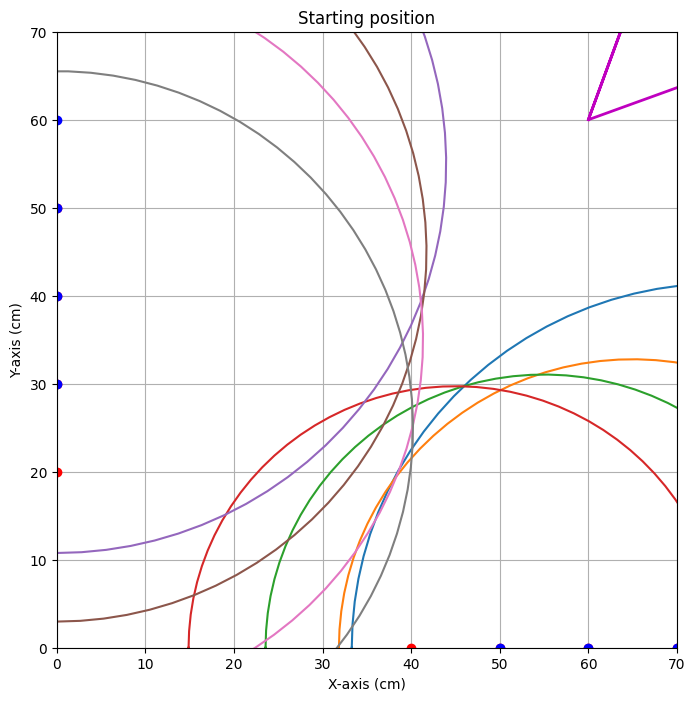


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.854


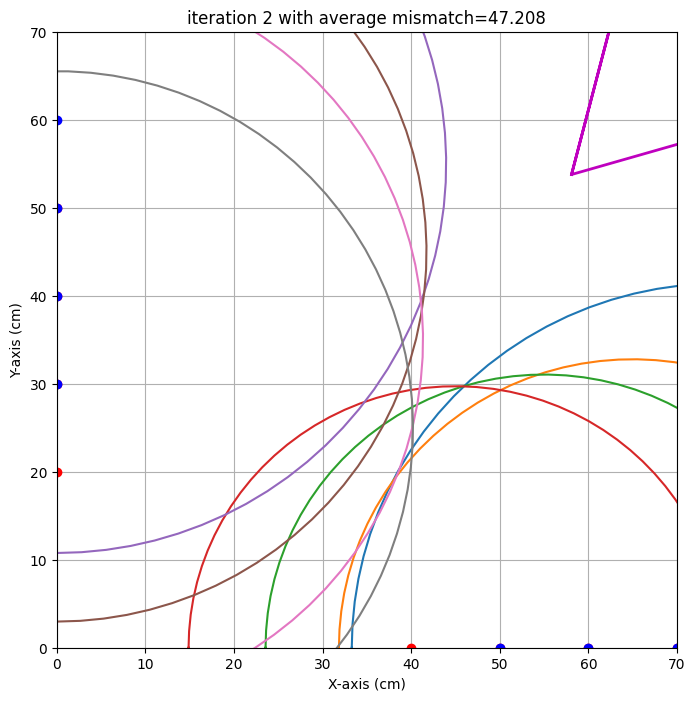

end iteration 2 with average mismatch=47.208


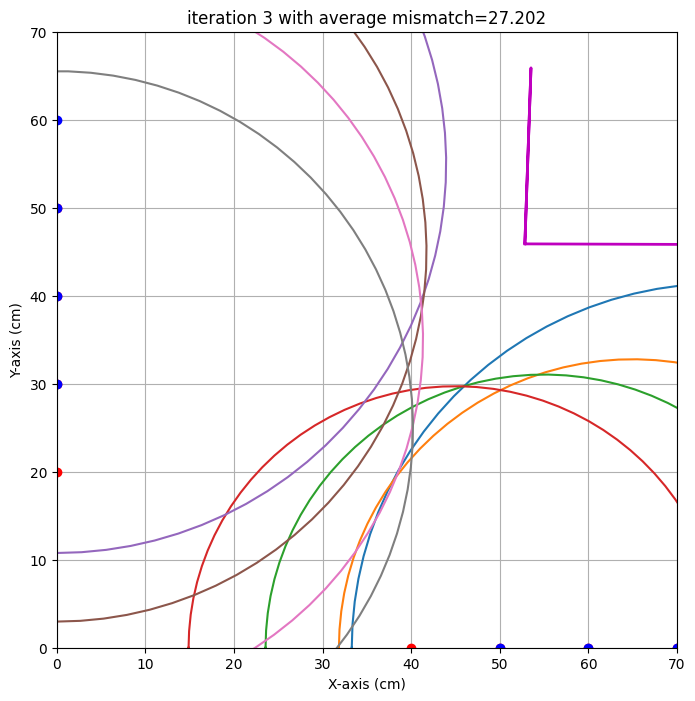

end iteration 3 with average mismatch=27.202


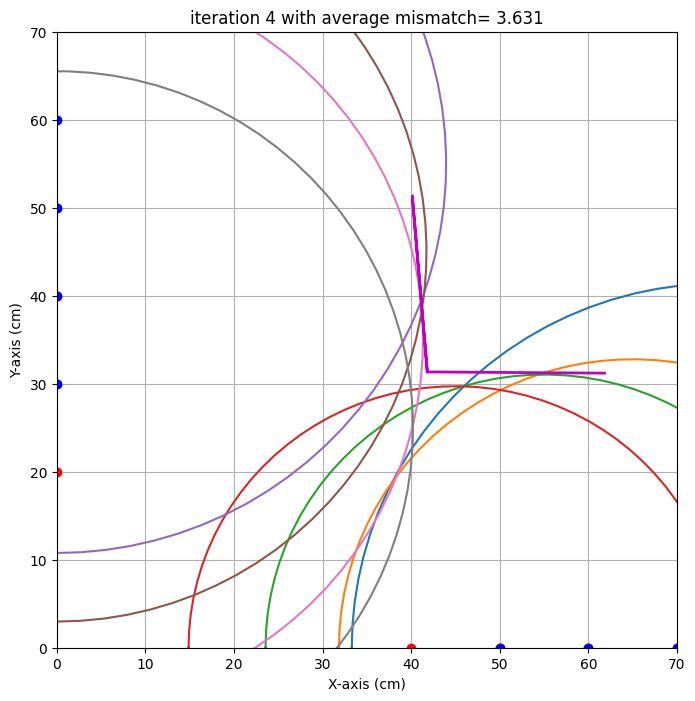

end iteration 4 with average mismatch= 3.631


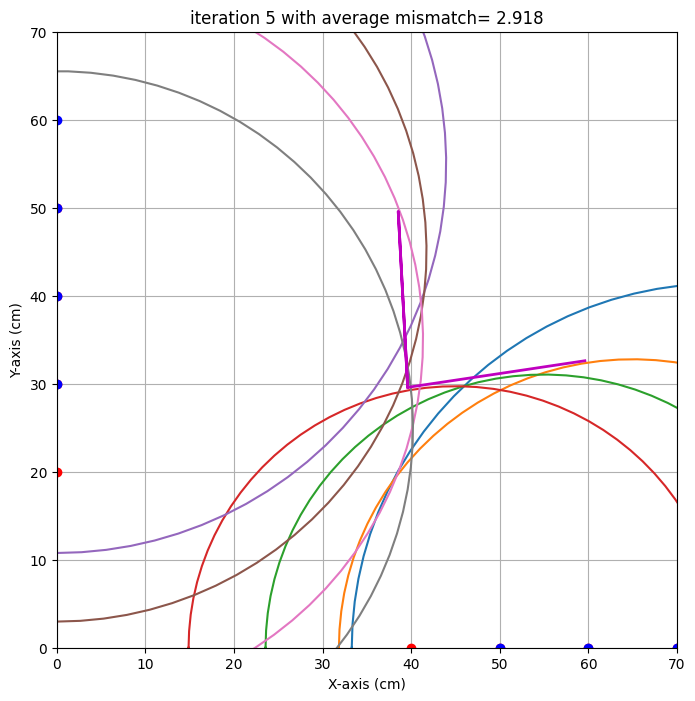

end iteration 5 with average mismatch= 2.918


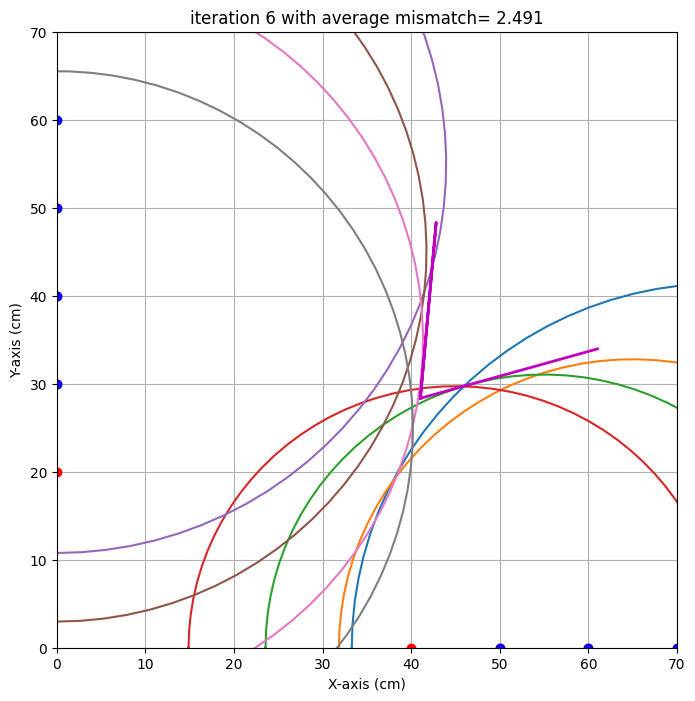

end iteration 6 with average mismatch= 2.491


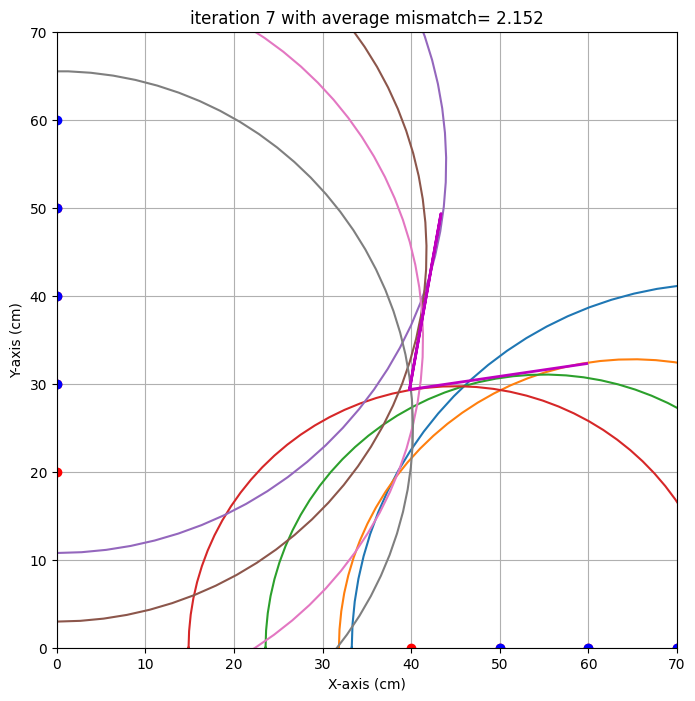

end iteration 7 with average mismatch= 2.152
end iteration 8 with average mismatch= 2.152
end iteration 9 with average mismatch= 2.152
end iteration 10 with average mismatch= 2.138
end iteration 11 with average mismatch= 2.109
end iteration 12 with average mismatch= 2.109
end iteration 13 with average mismatch= 2.109
end iteration 14 with average mismatch= 2.062
end iteration 15 with average mismatch= 2.062
end iteration 16 with average mismatch= 2.062
end iteration 17 with average mismatch= 2.062
end iteration 18 with average mismatch= 2.062
end iteration 19 with average mismatch= 2.062
end iteration 20 with average mismatch= 2.005
end iteration 21 with average mismatch= 2.005
end iteration 22 with average mismatch= 2.005
end iteration 23 with average mismatch= 2.005
end iteration 24 with average mismatch= 2.005
end iteration 25 with average mismatch= 2.005
end iteration 26 with average mismatch= 2.005
end iteration 27 with average mismatch= 2.002
end iteration 28 with average mismatc

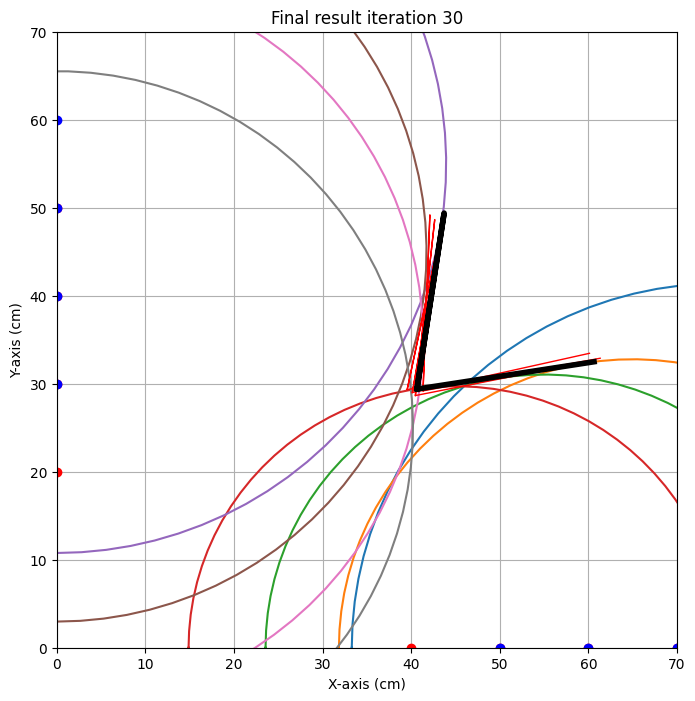

{'alpha': np.float64(8.821446761124887), 'alpha_eps': np.float64(3.7581471770423587), 'beta': np.float64(8.728873789829573), 'beta_eps': np.float64(6.505489592708903), 'x0': np.float64(40.64815628319264), 'x0_eps': np.float64(1.1023927667547966), 'y0': np.float64(29.391421955058902), 'y0_eps': np.float64(0.7375675401278095)}
Daan
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  55   0  40   0   63.16
1   0  55   0  40   87.04
2  35   0  40   0  129.53


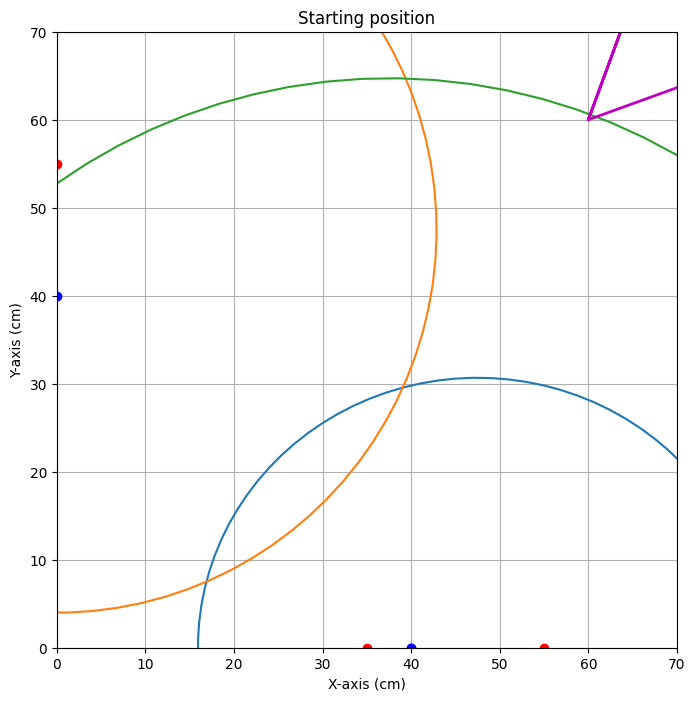


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.507


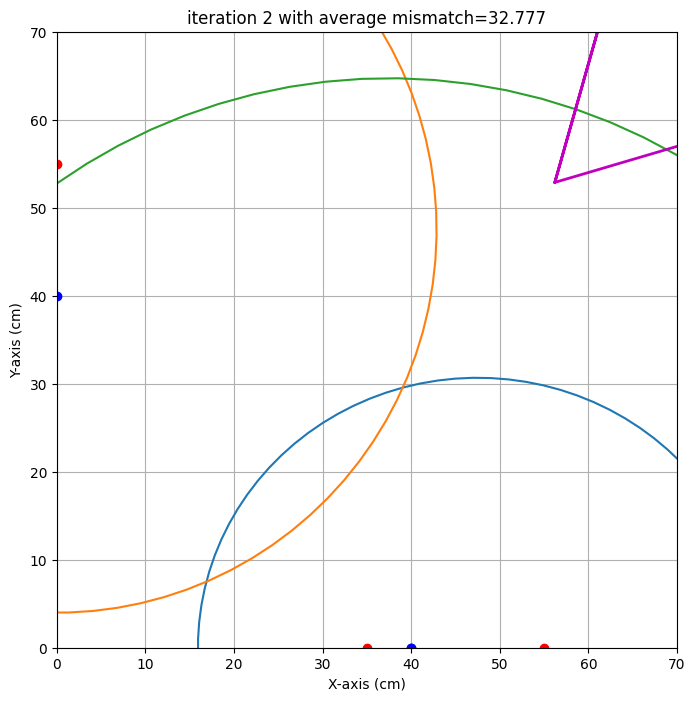

end iteration 2 with average mismatch=32.777


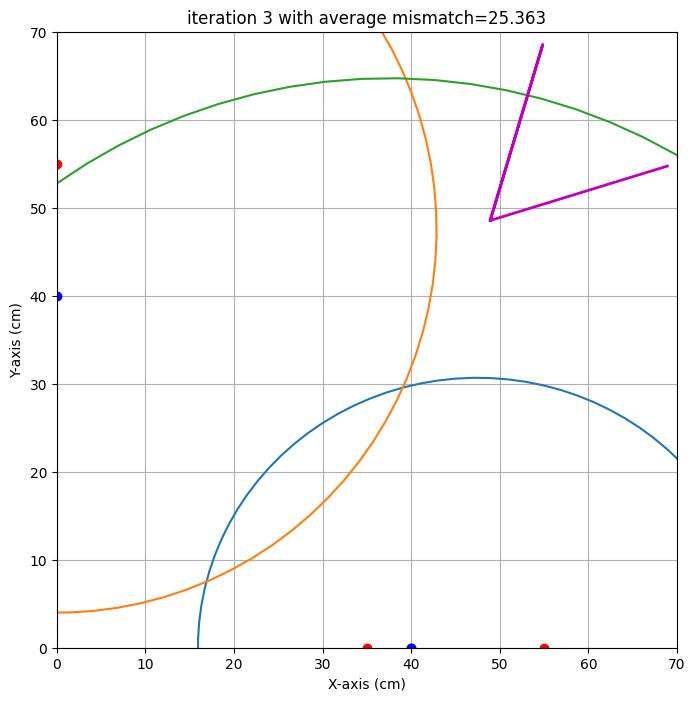

end iteration 3 with average mismatch=25.363


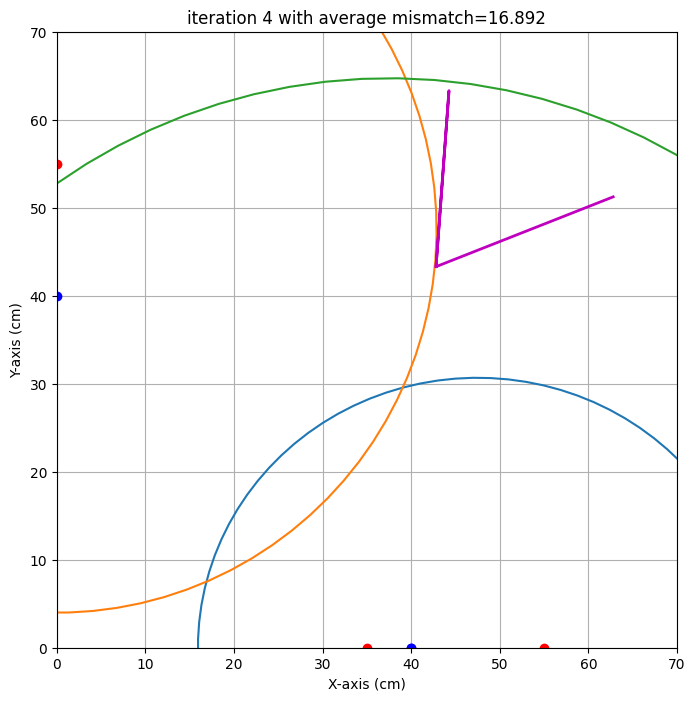

end iteration 4 with average mismatch=16.892
end iteration 5 with average mismatch=16.828
end iteration 6 with average mismatch=16.827
end iteration 7 with average mismatch=16.827
end iteration 8 with average mismatch=16.827
end iteration 9 with average mismatch=16.827
end iteration 10 with average mismatch=16.827
end iteration 11 with average mismatch=16.827
end iteration 12 with average mismatch=16.827
end iteration 13 with average mismatch=16.827
end iteration 14 with average mismatch=16.827
end iteration 15 with average mismatch=16.827
end iteration 16 with average mismatch=16.826
end iteration 17 with average mismatch=16.826
end iteration 18 with average mismatch=16.821
end iteration 19 with average mismatch=16.821
end iteration 20 with average mismatch=16.821
end iteration 21 with average mismatch=16.821
end iteration 22 with average mismatch=16.821
end iteration 23 with average mismatch=16.821
end iteration 24 with average mismatch=16.817
end iteration 25 with average mismatch=1

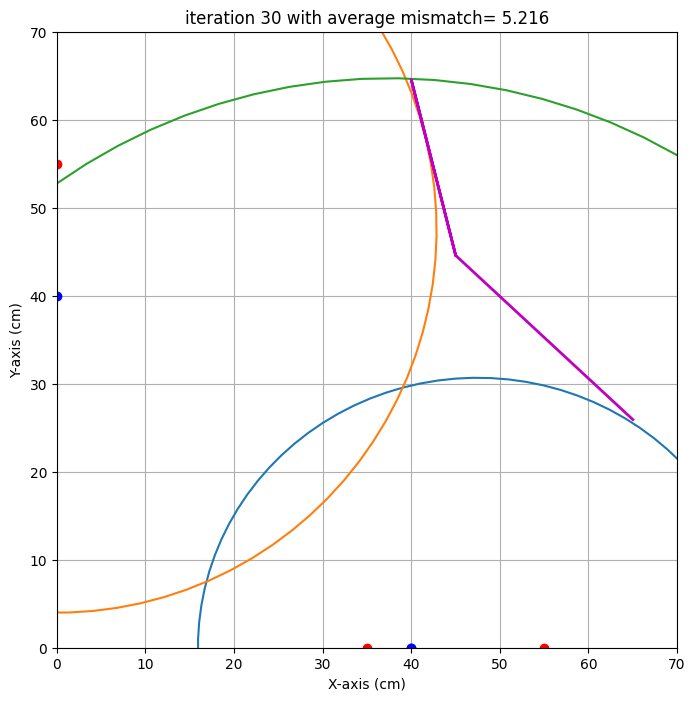

end iteration 30 with average mismatch= 5.216
###############################################################################
end of iteration  30
Best alpha= -43.00 with uncertainty=   2.52
Best beta = -14.10 with uncertainty=  14.37
Best x0   =  45.03 with uncertainty=   2.01
Best y0   =  44.58 with uncertainty=   0.77
###############################################################################


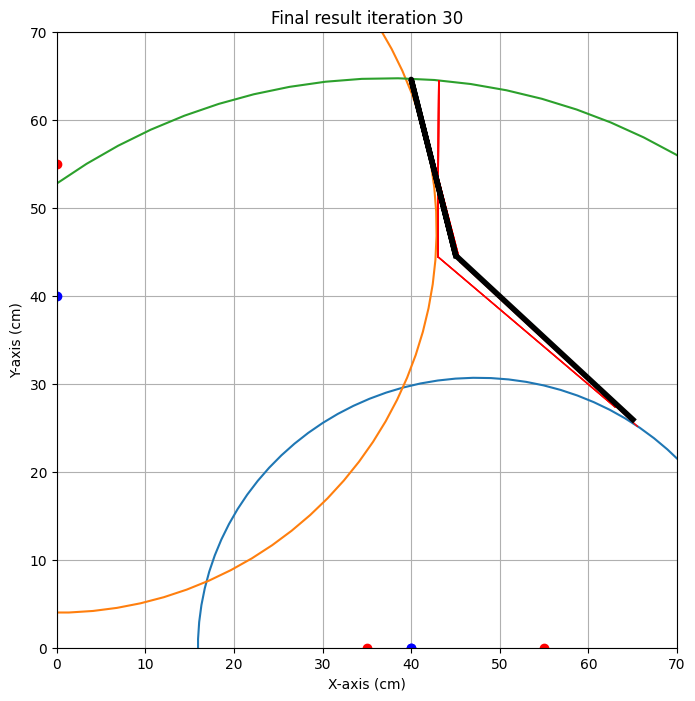

{'alpha': np.float64(-43.0), 'alpha_eps': np.float64(2.5169868990680584), 'beta': np.float64(-14.100048273402527), 'beta_eps': np.float64(14.368078326234286), 'x0': np.float64(45.02531461779759), 'x0_eps': np.float64(2.0109929220810088), 'y0': np.float64(44.576556152882596), 'y0_eps': np.float64(0.7687232574988414)}


In [87]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [83]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Oskar 
x0 target is : 37.0. Gevonden waarde: 40.3 cm met een standaardafwijking van 1.1 cm 
y0 target is : 26.0. Gevonden waarde: 28.9 cm met een standaardafwijking van 1.1 cm 
alpha target is : 25.0. Gevonden waarde: 10.1 graden met een standaardafwijking van 3.3 graad 
beta target is : 10.0. Gevonden waarde: 9.3 graden met een standaardafwijking van 8.2 graad 

Daan 
x0 target is : 37.0. Gevonden waarde: 61.5 cm met een standaardafwijking van 3.5 cm 
y0 target is : 26.0. Gevonden waarde: 28.7 cm met een standaardafwijking van 3.4 cm 
alpha target is : 25.0. Gevonden waarde: 43.0 graden met een standaardafwijking van 1.7 graad 
beta target is : 10.0. Gevonden waarde: -43.0 graden met een standaardafwijking van 1.4 graad 



## Opdracht 8: Iteratie1 14:55
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie1.jpg)


In [84]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [85]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (786680266.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")